# Semana 5 — Experimentos A/B

> **Estado del entregable:** este archivo se sube **con celdas ya ejecutadas** (tabla, figura embebida y resumen del JSONL) para revisión en GitHub sin correr el kernel. Tras `python scripts/run_week5_experiments.py`, ejecutar *Run all* para actualizar salidas.

**Qué es:** comparación **baseline vs Var1 vs Var2** sobre el corpus gold de criticidad (`gold_mode`: play / pausa / stop), con **un solo cambio** por variante en la representación TF-IDF. **Sin LLM** (costo 0 en esta corrida).

**Artefactos en repo (fuente de verdad):**
- Script: `scripts/run_week5_experiments.py`
- Tabla CSV: `docs/experiments/week5/results.csv`
- Informe: `docs/experiments/week5/week5_report.md`
- Gráfico: `docs/experiments/week5/comparison_f1_macro.png`
- Logs JSONL: `logs/week5/*.jsonl`

Este notebook **consolida** lectura de esos archivos para **presentación** (clase / revisión).

## Diseño experimental (A/B)

| Experimento | Único cambio vs baseline |
|-------------|---------------------------|
| **baseline** | TF-IDF *word* unigramas `(1,1)` + `LogisticRegression` (solver `lbfgs`) |
| **var1** | TF-IDF *word* n-gramas `(1,2)` |
| **var2** | TF-IDF *char* n-gramas `(3,5)` |

## Validación

- **Holdout:** `StratifiedShuffleSplit` (20 % test, `random_state=42`), estratificado por `gold_mode`.
- **GroupKFold (k=5)** por `template_index`: la misma plantilla no cruza train/test en un fold (mitiga fuga por plantilla).

**Métrica principal:** F1-macro multiclase. **Secundarias:** accuracy, tiempos (holdout = fit+predict en un split; GKF = suma de tiempos en los 5 folds).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "docs" / "experiments" / "week5" / "results.csv").is_file():
            return p
    raise FileNotFoundError(
        "No se encontró docs/experiments/week5/results.csv. "
        "Abre el notebook desde la raíz del repo o desde notebooks/."
    )


REPO = find_repo_root()
W5 = REPO / "docs" / "experiments" / "week5"
LOG_DIR = REPO / "logs" / "week5"

df = pd.read_csv(W5 / "results.csv")
order = {"baseline": 0, "var1": 1, "var2": 2}
df["_o"] = df["exp"].map(order)
df = df.sort_values("_o").drop(columns=["_o"]).reset_index(drop=True)

num = [c for c in df.columns if c != "exp"]
display(df.style.format({c: "{:.4f}" for c in num}).hide(axis="index"))

base_gkf = float(df.loc[df["exp"] == "baseline", "gkf_f1_macro_mean"].iloc[0])
idx_best = df["gkf_f1_macro_mean"].idxmax()
best = df.loc[idx_best]
mejora = (best["gkf_f1_macro_mean"] - base_gkf) / base_gkf * 100 if base_gkf else float("nan")
print(
    f"Resumen — baseline F1-macro (GKF μ)={base_gkf:.4f} | "
    f"mejor={best['exp']} F1-macro (GKF μ)={best['gkf_f1_macro_mean']:.4f} "
    f"(Δ vs baseline ≈ {mejora:+.1f}%)"
)
print(
    f"Holdout: todas las filas muestran F1-macro={df['holdout_f1_macro'].iloc[0]:.4f} (test pequeño; interpretar con week5_report)."
)

exp,holdout_f1_macro,holdout_accuracy,holdout_time_sec,gkf_f1_macro_mean,gkf_f1_macro_std,gkf_accuracy_mean,gkf_time_sec
baseline,1.0000,1.0000,0.0403,0.9866,0.0165,0.9867,0.1756
var1,1.0000,1.0000,0.0624,0.9899,0.0201,0.9900,0.2466
var2,1.0000,1.0000,0.5848,1.0000,0.0000,1.0000,3.5976


Resumen — baseline F1-macro (GKF μ)=0.9866 | mejor=var2 F1-macro (GKF μ)=1.0000 (Δ vs baseline ≈ +1.4%)
Holdout: todas las filas muestran F1-macro=1.0000 (test pequeño; interpretar con week5_report).


## Gráfico clave (F1-macro holdout vs media GKF ± σ)

Generado por el script al guardar `comparison_f1_macro.png`.

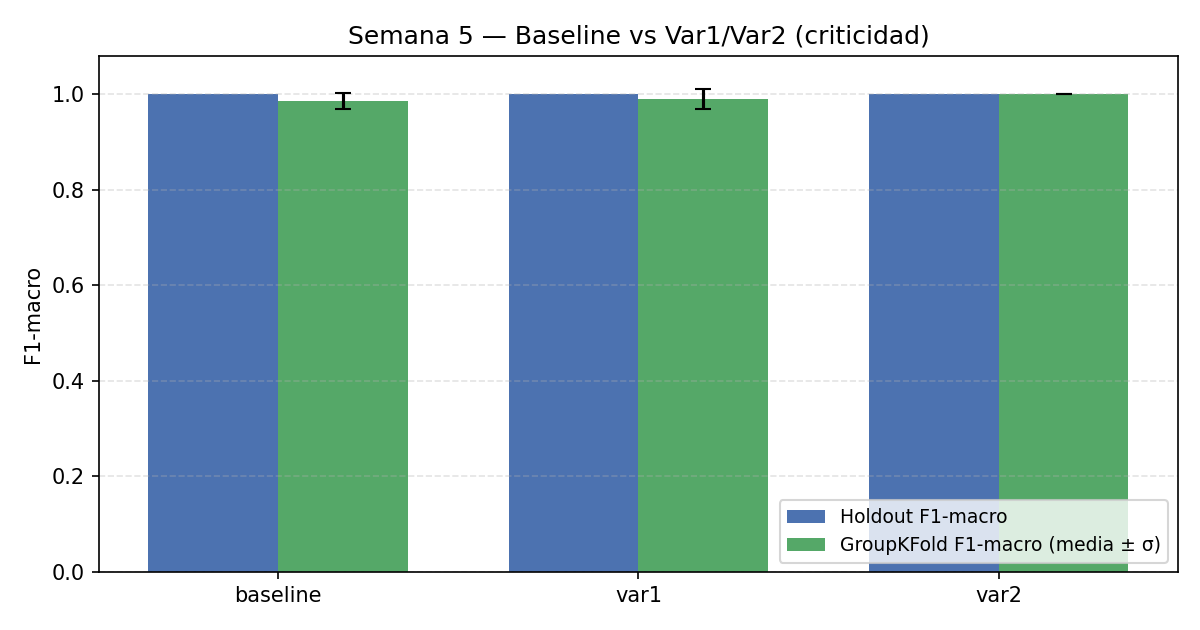

In [2]:
display(Image(filename=str(W5 / "comparison_f1_macro.png")))

## Logs (JSONL)

Cada línea es un JSON con configuración del experimento y métricas (holdout + GroupKFold).

In [3]:
log_files = sorted(LOG_DIR.glob("week5_experiments_*.jsonl"))
if not log_files:
    print("No hay logs en", LOG_DIR)
else:
    latest = log_files[-1]
    print("Log usado:", latest.relative_to(REPO).as_posix())
    rows = []
    with latest.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            o = json.loads(line)
            exp = o["experiment"]["name"]
            h = o["metrics"]["holdout"]
            g = o["metrics"]["group_kfold"]
            rows.append(
                {
                    "exp": exp,
                    "run_id": o.get("run_id"),
                    "holdout_f1": h["f1_macro"],
                    "gkf_f1_mean": g["f1_macro_mean"],
                    "gkf_f1_std": g["f1_macro_std"],
                }
            )
    display(pd.DataFrame(rows).style.format({"holdout_f1": "{:.4f}", "gkf_f1_mean": "{:.4f}", "gkf_f1_std": "{:.4f}"}).hide(axis="index"))

Log usado: logs/week5/week5_experiments_20260516_004409.jsonl


exp,run_id,holdout_f1,gkf_f1_mean,gkf_f1_std
baseline,20260516_004409,1.0000,0.9866,0.0165
var1,20260516_004409,1.0000,0.9899,0.0201
var2,20260516_004409,1.0000,1.0000,0.0000


## Reproducir desde cero

```bash
pip install -r requirements.txt
python scripts/run_week5_experiments.py
```

Eso actualiza `results.csv`, `week5_report.md`, el PNG y un nuevo `logs/week5/week5_experiments_<run_id>.jsonl`.